# E-commerce Sales & Customer Analytics

## SQL + Python Portfolio Project

This project analyzes a synthetic e-commerce database using PostgreSQL and Python.

The analysis covers:

- Sales performance
- Revenue and profitability
- Product and category performance
- Customer segmentation
- RFM analysis
- Order behavior
- Discount impact
- Predictive modeling for high-value customers

## 1. Data Loading and Database Connection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, URL
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

db_password = os.getenv("DB_PASSWORD")

url = URL.create(
    "postgresql+psycopg2",
    username="postgres",
    password=db_password,
    host="localhost",
    port=5432,
    database="ecommerce_analytics"
)

engine = create_engine(url)

print("Database engine created.")

Database engine created.


In [3]:
customers = pd.read_sql("SELECT * FROM customers", engine)
categories = pd.read_sql("SELECT * FROM categories", engine)
products = pd.read_sql("SELECT * FROM products", engine)
orders = pd.read_sql("SELECT * FROM orders", engine)
order_items = pd.read_sql("SELECT * FROM order_items", engine)

print("Customers:", customers.shape)
print("Categories:", categories.shape)
print("Products:", products.shape)
print("Orders:", orders.shape)
print("Order items:", order_items.shape)

Customers: (5000, 7)
Categories: (8, 2)
Products: (250, 6)
Orders: (20000, 7)
Order items: (59791, 6)


## 2. Data Quality Checks

In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  5000 non-null   int64 
 1   first_name   5000 non-null   object
 2   last_name    5000 non-null   object
 3   email        5000 non-null   object
 4   country      5000 non-null   object
 5   city         5000 non-null   object
 6   signup_date  5000 non-null   object
dtypes: int64(1), object(6)
memory usage: 273.6+ KB


In [5]:
customers["signup_date"] = pd.to_datetime(customers["signup_date"])

customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  5000 non-null   int64         
 1   first_name   5000 non-null   object        
 2   last_name    5000 non-null   object        
 3   email        5000 non-null   object        
 4   country      5000 non-null   object        
 5   city         5000 non-null   object        
 6   signup_date  5000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(5)
memory usage: 273.6+ KB


In [6]:
customers.isna().sum()

customer_id    0
first_name     0
last_name      0
email          0
country        0
city           0
signup_date    0
dtype: int64

In [7]:
customers.duplicated().sum()

0

In [8]:
customers["email"].duplicated().sum()

0

In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_id          20000 non-null  int64 
 1   customer_id       20000 non-null  int64 
 2   order_date        20000 non-null  object
 3   order_status      20000 non-null  object
 4   payment_method    20000 non-null  object
 5   shipping_country  20000 non-null  object
 6   shipping_city     20000 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.1+ MB


In [10]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          20000 non-null  int64         
 1   customer_id       20000 non-null  int64         
 2   order_date        20000 non-null  datetime64[ns]
 3   order_status      20000 non-null  object        
 4   payment_method    20000 non-null  object        
 5   shipping_country  20000 non-null  object        
 6   shipping_city     20000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 1.1+ MB


In [11]:
orders.isna().sum()

order_id            0
customer_id         0
order_date          0
order_status        0
payment_method      0
shipping_country    0
shipping_city       0
dtype: int64

In [12]:
orders.duplicated().sum()

0

In [13]:
orders["order_id"].duplicated().sum()

0

In [14]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59791 entries, 0 to 59790
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  59791 non-null  int64  
 1   order_id       59791 non-null  int64  
 2   product_id     59791 non-null  int64  
 3   quantity       59791 non-null  int64  
 4   unit_price     59791 non-null  float64
 5   discount_pct   59791 non-null  float64
dtypes: float64(2), int64(4)
memory usage: 2.7 MB


In [15]:
print(order_items.isna().sum())
print("Duplicate rows:", order_items.duplicated().sum())
print("Duplicate IDs:", order_items["order_item_id"].duplicated().sum())

order_item_id    0
order_id         0
product_id       0
quantity         0
unit_price       0
discount_pct     0
dtype: int64
Duplicate rows: 0
Duplicate IDs: 0


In [16]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      250 non-null    int64  
 1   product_name    250 non-null    object 
 2   category_id     250 non-null    int64  
 3   price           250 non-null    float64
 4   cost            250 non-null    float64
 5   stock_quantity  250 non-null    int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 11.8+ KB


In [17]:
print(products.isna().sum())
print("Duplicate rows:", products.duplicated().sum())
print("Duplicate IDs:", products["product_id"].duplicated().sum())

product_id        0
product_name      0
category_id       0
price             0
cost              0
stock_quantity    0
dtype: int64
Duplicate rows: 0
Duplicate IDs: 0


In [18]:
categories.info()

print(categories.isna().sum())
print("Duplicate rows:", categories.duplicated().sum())
print("Duplicate IDs:", categories["category_id"].duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   category_id    8 non-null      int64 
 1   category_name  8 non-null      object
dtypes: int64(1), object(1)
memory usage: 256.0+ bytes
category_id      0
category_name    0
dtype: int64
Duplicate rows: 0
Duplicate IDs: 0


## 3. Exploratory Data Analysis

In [19]:
products[["price", "cost", "stock_quantity"]].describe()

,price,cost,stock_quantity
count,250.000000,250.000000,250.00000
mean,250.843440,158.501120,260.00400
std,135.657824,91.297507,142.44276
min,10.830000,7.390000,1.00000
25%,135.252500,81.382500,138.00000
50%,238.960000,145.025000,273.00000
75%,357.487500,223.812500,381.75000
max,499.950000,375.350000,496.00000


In [20]:
products["unit_margin"] = products["price"] - products["cost"]

products["margin_pct"] = (
    products["unit_margin"] / products["price"] * 100
)

products[["price", "cost", "unit_margin", "margin_pct"]].describe()

,price,cost,unit_margin,margin_pct
count,250.000000,250.000000,250.000000,250.000000
mean,250.843440,158.501120,92.342320,36.923224
std,135.657824,91.297507,57.103492,10.123520
min,10.830000,7.390000,2.450000,20.034493
25%,135.252500,81.382500,47.107500,27.661372
50%,238.960000,145.025000,84.205000,37.845020
75%,357.487500,223.812500,125.917500,45.384243
max,499.950000,375.350000,239.640000,54.749615


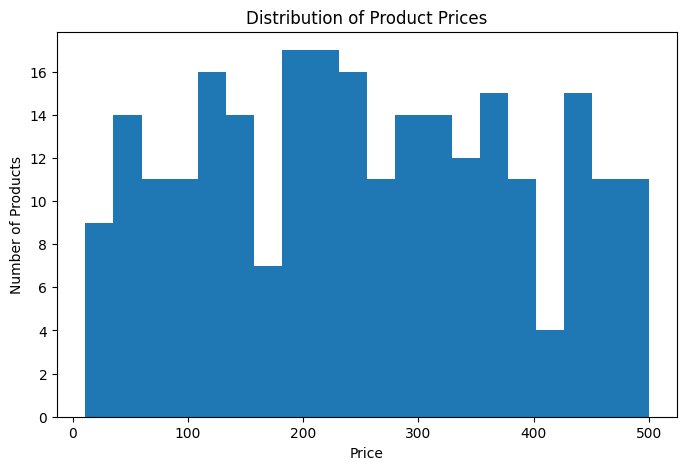

In [21]:
plt.figure(figsize=(8, 5))
plt.hist(products["price"], bins=20)

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.show()

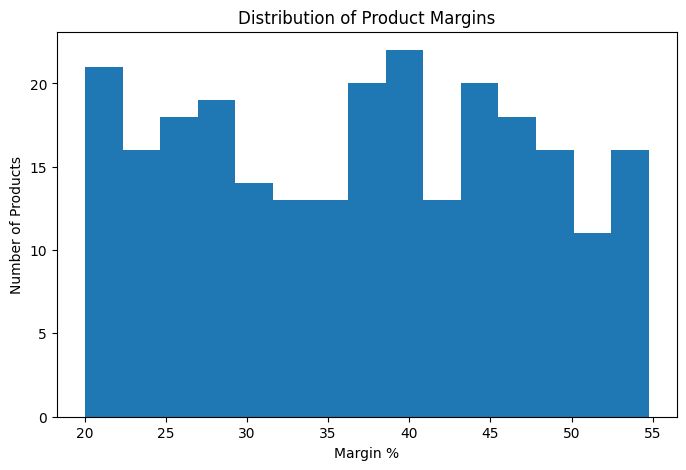

In [22]:
plt.figure(figsize=(8, 5))
plt.hist(products["margin_pct"], bins=15)

plt.title("Distribution of Product Margins")
plt.xlabel("Margin %")
plt.ylabel("Number of Products")

plt.show()

## 4. Product and Category Analysis

In [23]:
category_margin = (
    products
    .merge(categories, on="category_id")
    .groupby("category_name", as_index=False)["margin_pct"]
    .mean()
    .sort_values("margin_pct", ascending=False)
)

category_margin

,category_name,margin_pct
5,Office Supplies,39.649624
6,Sports,38.920502
4,Home & Kitchen,38.211954
1,Books,37.256389
3,Electronics,36.966689
2,Clothing,36.745369
0,Beauty,35.296787
7,Toys,33.073823


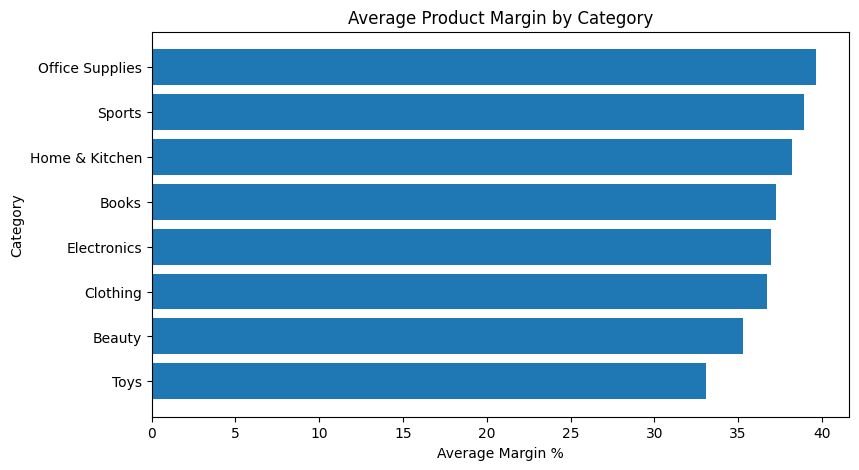

In [24]:
plt.figure(figsize=(9, 5))

plt.barh(
    category_margin["category_name"],
    category_margin["margin_pct"]
)

plt.title("Average Product Margin by Category")
plt.xlabel("Average Margin %")
plt.ylabel("Category")

plt.gca().invert_yaxis()
plt.show()

## 5. Sales Trend Analysis

In [25]:
sales = (
    order_items
    .merge(orders[["order_id", "order_date"]], on="order_id")
)

sales["revenue"] = (
    sales["quantity"]
    * sales["unit_price"]
    * (1 - sales["discount_pct"] / 100)
)

monthly_revenue = (
    sales
    .groupby(sales["order_date"].dt.to_period("M"))["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["order_date"] = monthly_revenue["order_date"].dt.to_timestamp()

monthly_revenue.head()

,order_date,revenue
0,2022-09-01,102452.1085
1,2022-10-01,665078.6685
2,2022-11-01,701426.0930
3,2022-12-01,810419.5020
4,2023-01-01,763437.1575


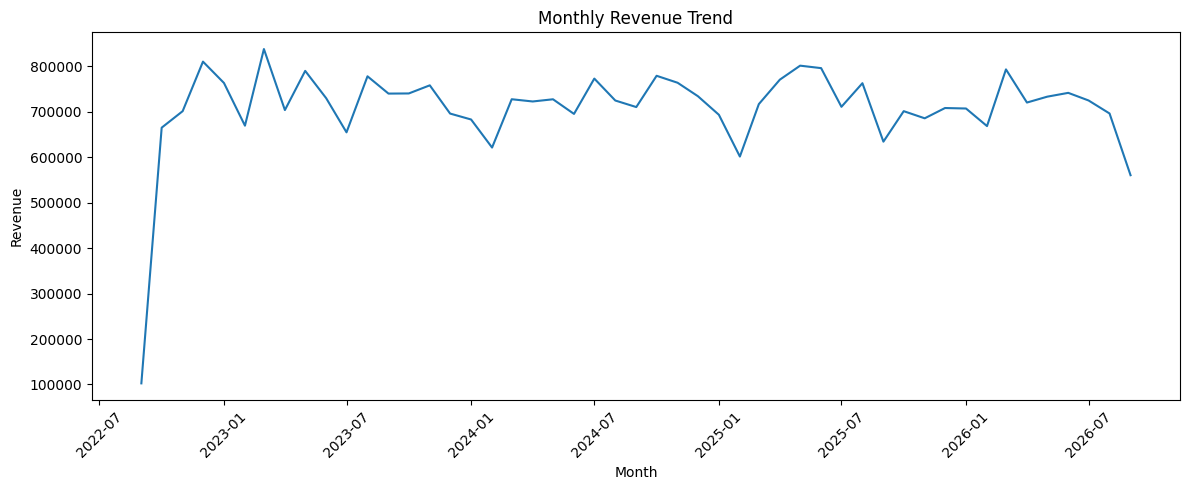

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["order_date"],
    monthly_revenue["revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

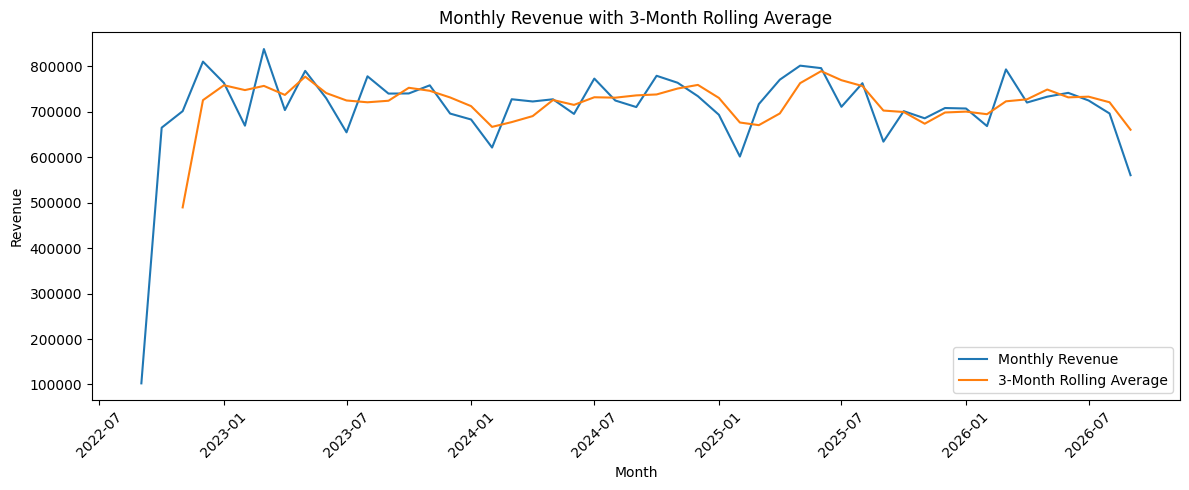

In [27]:
monthly_revenue["rolling_3m"] = (
    monthly_revenue["revenue"]
    .rolling(window=3)
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["order_date"],
    monthly_revenue["revenue"],
    label="Monthly Revenue"
)

plt.plot(
    monthly_revenue["order_date"],
    monthly_revenue["rolling_3m"],
    label="3-Month Rolling Average"
)

plt.title("Monthly Revenue with 3-Month Rolling Average")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

In [28]:
category_sales = (
    order_items
    .merge(products[["product_id", "category_id"]], on="product_id")
    .merge(categories, on="category_id")
)

category_sales["revenue"] = (
    category_sales["quantity"]
    * category_sales["unit_price"]
    * (1 - category_sales["discount_pct"] / 100)
)

category_revenue = (
    category_sales
    .groupby("category_name", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

category_revenue

,category_name,revenue
7,Toys,5.208773e+06
4,Home & Kitchen,5.184005e+06
1,Books,5.172385e+06
3,Electronics,4.155394e+06
2,Clothing,3.977779e+06
6,Sports,3.939473e+06
0,Beauty,3.806399e+06
5,Office Supplies,3.291514e+06


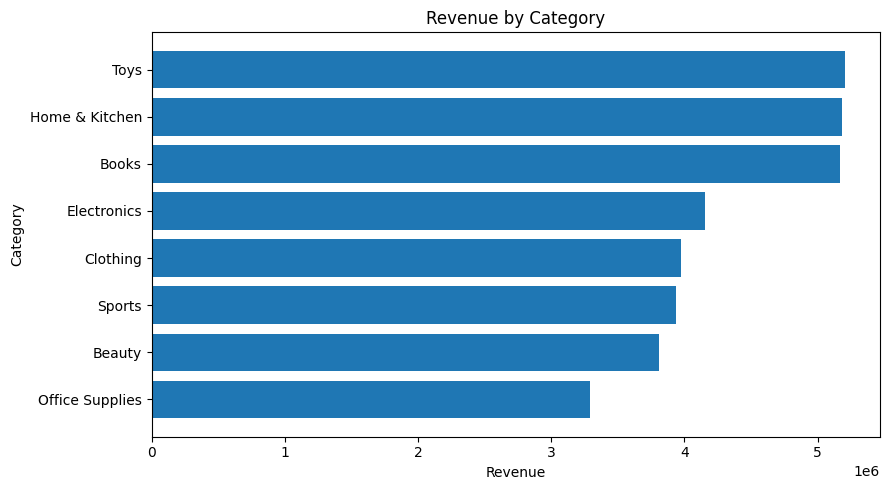

In [29]:
plt.figure(figsize=(9, 5))

plt.barh(
    category_revenue["category_name"],
    category_revenue["revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

In [30]:
category_profit = (
    category_sales
    .merge(
        products[["product_id", "cost"]],
        on="product_id",
        how="left"
    )
)

category_profit["gross_profit"] = (
    category_profit["quantity"]
    * (
        category_profit["unit_price"]
        * (1 - category_profit["discount_pct"] / 100)
        - category_profit["cost"]
    )
)

category_profit_summary = (
    category_profit
    .groupby("category_name", as_index=False)["gross_profit"]
    .sum()
    .sort_values("gross_profit", ascending=False)
)

category_profit_summary

,category_name,gross_profit
4,Home & Kitchen,1.780569e+06
1,Books,1.685501e+06
7,Toys,1.505222e+06
6,Sports,1.368817e+06
3,Electronics,1.348193e+06
2,Clothing,1.193495e+06
0,Beauty,1.121574e+06
5,Office Supplies,1.103265e+06


In [31]:
category_profit = (
    category_sales
    .merge(
        products[["product_id", "cost"]],
        on="product_id",
        how="left"
    )
)

category_profit["gross_profit"] = (
    category_profit["quantity"]
    * (
        category_profit["unit_price"]
        * (1 - category_profit["discount_pct"] / 100)
        - category_profit["cost"]
    )
)

category_profit_summary = (
    category_profit
    .groupby("category_name", as_index=False)["gross_profit"]
    .sum()
    .sort_values("gross_profit", ascending=False)
)

category_profit_summary

,category_name,gross_profit
4,Home & Kitchen,1.780569e+06
1,Books,1.685501e+06
7,Toys,1.505222e+06
6,Sports,1.368817e+06
3,Electronics,1.348193e+06
2,Clothing,1.193495e+06
0,Beauty,1.121574e+06
5,Office Supplies,1.103265e+06


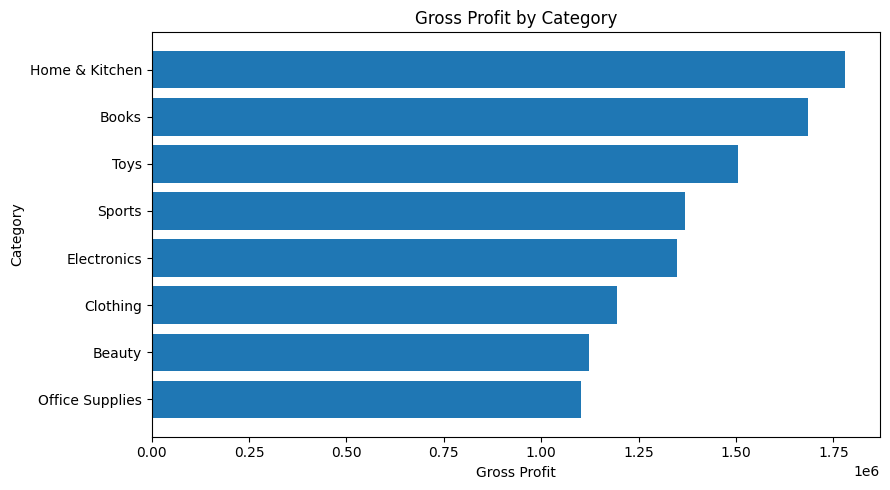

In [32]:
plt.figure(figsize=(9, 5))

plt.barh(
    category_profit_summary["category_name"],
    category_profit_summary["gross_profit"]
)

plt.title("Gross Profit by Category")
plt.xlabel("Gross Profit")
plt.ylabel("Category")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

In [ ]:
product_sales = (
    category_profit
    .groupby(
        ["product_id", "product_name", "category_name"],
        as_index=False
    )
    .agg(
        units_sold=("quantity", "sum"),
        revenue=("revenue", "sum"),
        gross_profit=("gross_profit", "sum")
    )
)

top_products = (
    product_sales
    .sort_values("revenue", ascending=False)
    .head(10)
)

top_products

In [ ]:
product_sales["gross_margin_pct"] = (
    product_sales["gross_profit"]
    / product_sales["revenue"]
    * 100
)

product_sales[
    ["product_name", "category_name", "revenue", "gross_profit", "gross_margin_pct"]
].sort_values("revenue", ascending=False).head(10)

## 6. Customer Analysis

In [35]:
customer_sales = (
    sales
    .groupby("order_id", as_index=False)["revenue"]
    .sum()
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id"
    )
)

customer_spend = (
    customer_sales
    .groupby("customer_id", as_index=False)
    .agg(
        total_orders=("order_id", "nunique"),
        total_spent=("revenue", "sum")
    )
)

customer_spend.describe()

,customer_id,total_orders,total_spent
count,4898.000000,4898.000000,4898.000000
mean,2496.672111,4.083299,7091.817620
std,1441.708057,1.910495,3924.879099
min,1.000000,1.000000,23.480000
25%,1248.250000,3.000000,4180.090000
50%,2497.500000,4.000000,6665.479250
75%,3740.750000,5.000000,9526.741875
max,5000.000000,13.000000,26180.619500


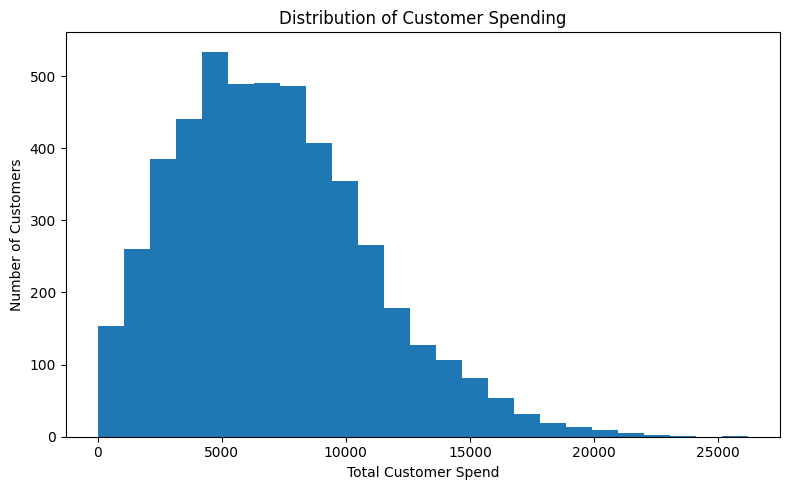

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(
    customer_spend["total_spent"],
    bins=25
)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Customer Spend")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [37]:
["product_id", "category_id"]

['product_id', 'category_id']

In [38]:
product_sales_data = (
    order_items
    .merge(
        products[
            ["product_id", "product_name", "category_id", "cost"]
        ],
        on="product_id"
    )
    .merge(
        categories,
        on="category_id"
    )
)

product_sales_data["revenue"] = (
    product_sales_data["quantity"]
    * product_sales_data["unit_price"]
    * (1 - product_sales_data["discount_pct"] / 100)
)

product_sales_data["gross_profit"] = (
    product_sales_data["quantity"]
    * (
        product_sales_data["unit_price"]
        * (1 - product_sales_data["discount_pct"] / 100)
        - product_sales_data["cost"]
    )
)

product_sales = (
    product_sales_data
    .groupby(
        ["product_id", "product_name", "category_name"],
        as_index=False
    )
    .agg(
        units_sold=("quantity", "sum"),
        revenue=("revenue", "sum"),
        gross_profit=("gross_profit", "sum")
    )
)

product_sales["gross_margin_pct"] = (
    product_sales["gross_profit"]
    / product_sales["revenue"]
    * 100
)

product_sales.sort_values(
    "revenue",
    ascending=False
).head(10)

,product_id,product_name,category_name,units_sold,revenue,gross_profit,gross_margin_pct
194,195,Product 195,Home & Kitchen,689,302995.6160,132164.9560,43.619428
215,216,Product 216,Home & Kitchen,664,300286.5235,109658.7635,36.518044
14,15,Product 15,Books,675,273155.2590,102123.7590,37.386708
209,210,Product 210,Office Supplies,643,272161.7280,120645.2080,44.328499
58,59,Product 59,Electronics,600,271639.0430,46429.0430,17.092183
127,128,Product 128,Clothing,617,270499.5520,46929.6020,17.349235
76,77,Product 77,Clothing,654,269542.7670,50688.2070,18.805256
29,30,Product 30,Beauty,591,266915.0020,51205.9120,19.184351
32,33,Product 33,Electronics,601,266491.8025,49440.6525,18.552410
143,144,Product 144,Sports,581,265044.1650,83510.7150,31.508226


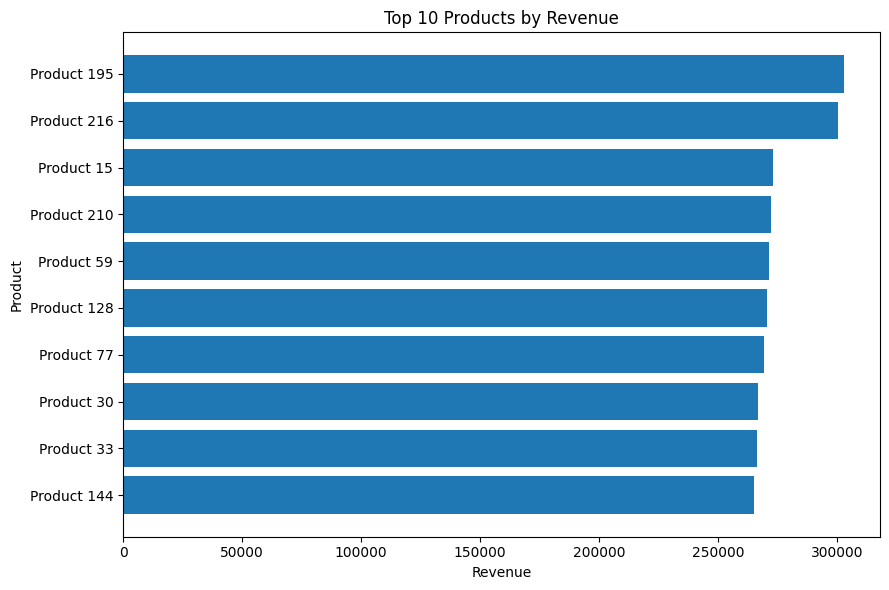

In [39]:
top_products = (
    product_sales
    .sort_values("revenue", ascending=False)
    .head(10)
    .sort_values("revenue")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_products["product_name"],
    top_products["revenue"]
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

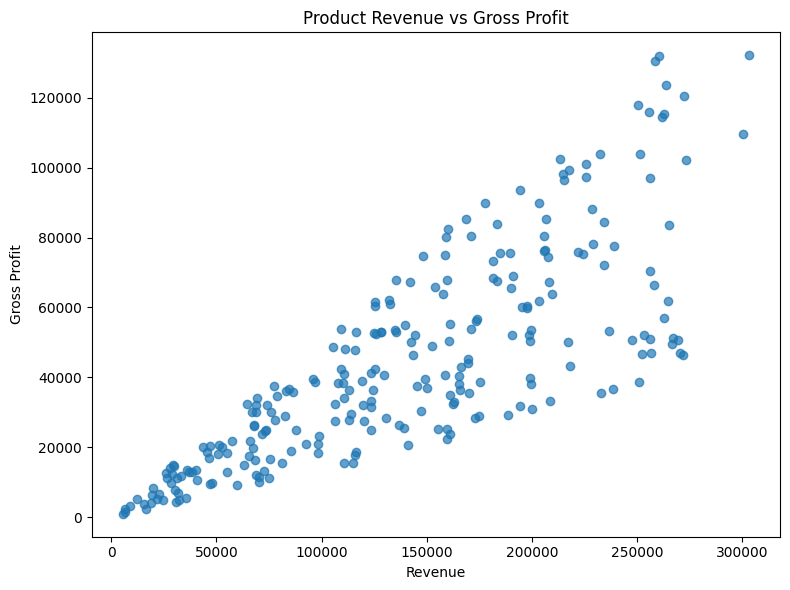

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(
    product_sales["revenue"],
    product_sales["gross_profit"],
    alpha=0.7
)

plt.title("Product Revenue vs Gross Profit")
plt.xlabel("Revenue")
plt.ylabel("Gross Profit")

plt.tight_layout()
plt.show()

In [ ]:
customer_summary["value_segment"] = pd.cut(
    customer_summary["total_spent"],
    bins=[-np.inf, 7000, 15000, np.inf],
    labels=["Low Value", "Medium Value", "High Value"]
)

customer_segments = (
    customer_summary
    .groupby(
        "value_segment",
        observed=False
    )
    .agg(
        customers=("customer_id", "count"),
        total_revenue=("total_spent", "sum"),
        avg_customer_value=("total_spent", "mean")
    )
    .reset_index()
)

customer_segments

In [42]:
customer_spend["value_segment"] = pd.cut(
    customer_spend["total_spent"],
    bins=[-np.inf, 7000, 15000, np.inf],
    labels=["Low Value", "Medium Value", "High Value"]
)

customer_segments = (
    customer_spend
    .groupby(
        "value_segment",
        observed=False
    )
    .agg(
        customers=("customer_id", "count"),
        total_revenue=("total_spent", "sum"),
        avg_customer_value=("total_spent", "mean")
    )
    .reset_index()
)

customer_segments

,value_segment,customers,total_revenue,avg_customer_value
0,Low Value,2604,1.078955e+07,4143.451075
1,Medium Value,2103,2.067207e+07,9829.799378
2,High Value,191,3.274108e+06,17141.926762


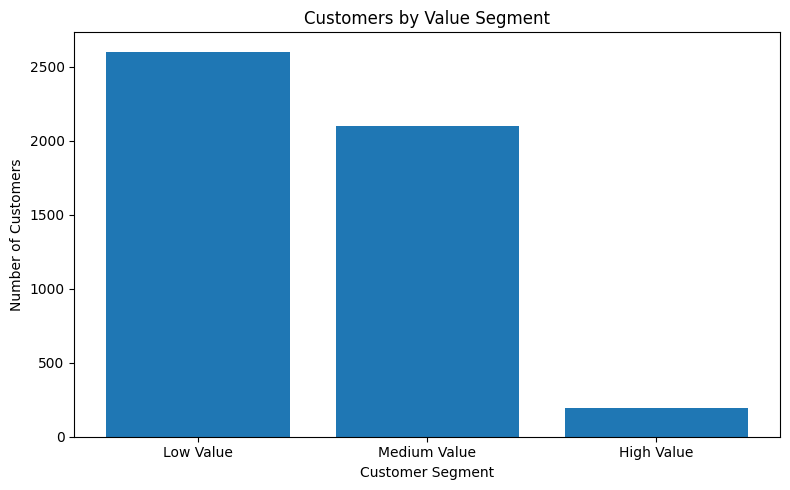

In [43]:
plt.figure(figsize=(8, 5))

plt.bar(
    customer_segments["value_segment"],
    customer_segments["customers"]
)

plt.title("Customers by Value Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## 7. RFM Segmentation

In [44]:
analysis_date = orders["order_date"].max() + pd.Timedelta(days=1)

customer_orders = (
    orders[["order_id", "customer_id", "order_date"]]
    .merge(
        sales[["order_id", "revenue"]],
        on="order_id"
    )
)

rfm = (
    customer_orders
    .groupby("customer_id")
    .agg(
        last_order_date=("order_date", "max"),
        frequency=("order_id", "nunique"),
        monetary=("revenue", "sum")
    )
    .reset_index()
)

rfm["recency"] = (
    analysis_date - rfm["last_order_date"]
).dt.days

rfm.head()

,customer_id,last_order_date,frequency,monetary,recency
0,1,2026-04-09,6,10910.0310,170
1,3,2025-08-04,5,6740.7315,418
2,4,2025-11-10,5,5429.0455,320
3,5,2025-08-27,4,7111.8785,395
4,6,2026-05-10,6,9121.2825,139


In [49]:
rfm["r_score"] = pd.qcut(
    rfm["recency"],
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["m_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["rfm_score"] = (
    rfm["r_score"]
    + rfm["f_score"]
    + rfm["m_score"]
)

rfm.sort_values(
    "rfm_score",
    ascending=False
).head(10)

,customer_id,last_order_date,frequency,monetary,recency,r_score,f_score,m_score,rfm_score,segment
1967,2005,2026-09-04,10,22766.7170,22,5,5,5,15,Champions
1734,1767,2026-08-03,8,17379.3165,54,5,5,5,15,Champions
4292,4376,2026-08-07,6,15144.7305,50,5,5,5,15,Champions
1408,1435,2026-08-23,7,10483.3085,34,5,5,5,15,Champions
1061,1083,2026-07-11,6,11664.3465,77,5,5,5,15,Champions
2875,2931,2026-07-14,8,12450.3985,74,5,5,5,15,Champions
4320,4404,2026-08-09,6,10471.0520,48,5,5,5,15,Champions
1395,1422,2026-08-07,6,11952.1185,50,5,5,5,15,Champions
2838,2894,2026-08-04,8,15394.5545,53,5,5,5,15,Champions
1729,1762,2026-09-12,6,12859.6810,14,5,5,5,15,Champions


In [50]:
rfm["r_score"] = pd.qcut(
    rfm["recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["m_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["rfm_score"] = (
    rfm["r_score"]
    + rfm["f_score"]
    + rfm["m_score"]
)

In [51]:
def assign_segment(row):
    if row["r_score"] >= 4 and row["f_score"] >= 4 and row["m_score"] >= 4:
        return "Champions"
    elif row["r_score"] >= 3 and row["f_score"] >= 4:
        return "Loyal Customers"
    elif row["r_score"] >= 4 and row["f_score"] <= 2:
        return "Promising"
    elif row["r_score"] <= 2 and row["f_score"] >= 3 and row["m_score"] >= 3:
        return "At Risk"
    elif row["r_score"] <= 2 and row["f_score"] <= 2:
        return "Hibernating"
    else:
        return "Potential Loyalists"

rfm["segment"] = rfm.apply(assign_segment, axis=1)

rfm_segments = (
    rfm
    .groupby("segment")
    .agg(
        customers=("customer_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean")
    )
    .reset_index()
    .sort_values("customers", ascending=False)
)

rfm_segments

,segment,customers,avg_recency,avg_frequency,avg_monetary
2,Hibernating,1097,700.293528,2.154057,3825.600511
4,Potential Loyalists,1070,235.298131,3.493458,5587.780315
1,Champions,839,83.115614,6.421931,11742.315997
0,At Risk,703,515.704125,5.001422,9378.251078
3,Loyal Customers,649,198.930663,5.637904,8790.450365
5,Promising,540,90.977778,2.474074,4463.700165


In [48]:
rfm["r_score"] = pd.qcut(
    rfm["recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["m_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["rfm_score"] = (
    rfm["r_score"]
    + rfm["f_score"]
    + rfm["m_score"]
)

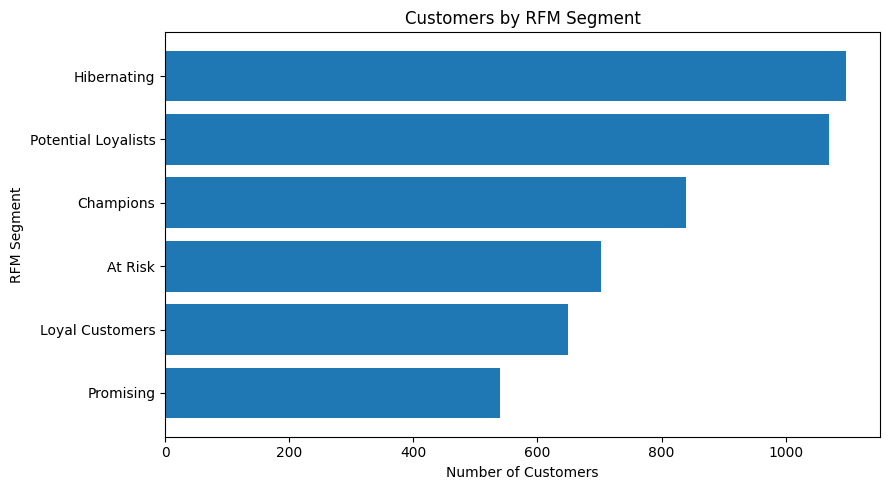

In [52]:
rfm_plot = (
    rfm_segments
    .sort_values("customers")
)

plt.figure(figsize=(9, 5))

plt.barh(
    rfm_plot["segment"],
    rfm_plot["customers"]
)

plt.title("Customers by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("RFM Segment")

plt.tight_layout()
plt.show()

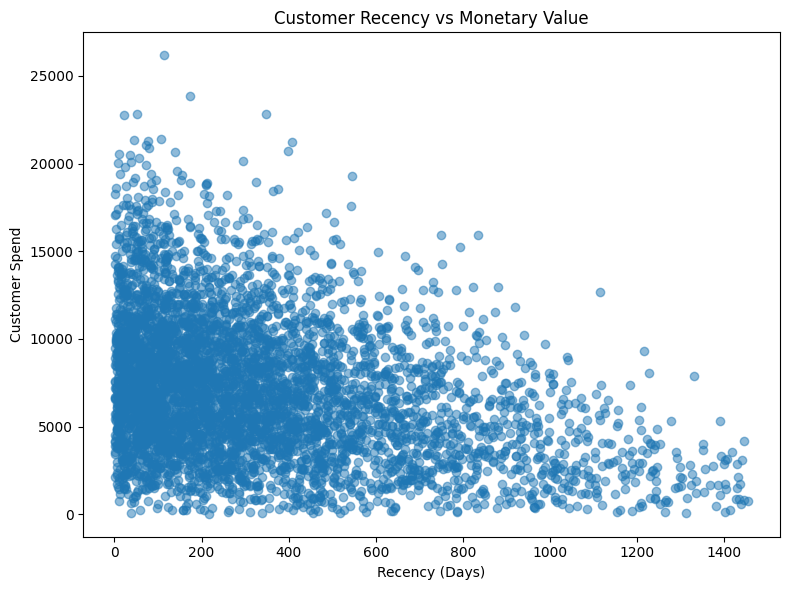

In [53]:
plt.figure(figsize=(8, 6))

plt.scatter(
    rfm["recency"],
    rfm["monetary"],
    alpha=0.5
)

plt.title("Customer Recency vs Monetary Value")
plt.xlabel("Recency (Days)")
plt.ylabel("Customer Spend")

plt.tight_layout()
plt.show()

## 8. Predictive Modeling

In [54]:
customer_spend["is_high_value"] = (
    customer_spend["total_spent"] >= 15000
).astype(int)

customer_spend["is_high_value"].value_counts()

is_high_value
0    4707
1     191
Name: count, dtype: int64

In [55]:
import sklearn

print(sklearn.__version__)

1.0.2


In [56]:
model_data = (
    rfm[
        ["customer_id", "recency", "frequency"]
    ]
    .merge(
        customer_spend[
            ["customer_id", "is_high_value"]
        ],
        on="customer_id"
    )
)

model_data.head()

,customer_id,recency,frequency,is_high_value
0,1,170,6,0
1,3,418,5,0
2,4,320,5,0
3,5,395,4,0
4,6,139,6,0


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X = model_data[["recency", "frequency"]]
y = model_data["is_high_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

[[1069  108]
 [   7   41]]

              precision    recall  f1-score   support

           0       0.99      0.91      0.95      1177
           1       0.28      0.85      0.42        48

    accuracy                           0.91      1225
   macro avg       0.63      0.88      0.68      1225
weighted avg       0.97      0.91      0.93      1225



In [58]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(auc, 3))

coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0]
})

coefficients

ROC-AUC: 0.958


,feature,coefficient
0,recency,0.000714
1,frequency,1.471890


In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

scaled_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logistic_regression",
        LogisticRegression(
            class_weight="balanced",
            random_state=42
        )
    )
])

scaled_model.fit(X_train, y_train)

y_pred_scaled = scaled_model.predict(X_test)
y_prob_scaled = scaled_model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_scaled))
print()
print(classification_report(y_test, y_pred_scaled))
print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_prob_scaled), 3)
)

[[1069  108]
 [   7   41]]

              precision    recall  f1-score   support

           0       0.99      0.91      0.95      1177
           1       0.28      0.85      0.42        48

    accuracy                           0.91      1225
   macro avg       0.63      0.88      0.68      1225
weighted avg       0.97      0.91      0.93      1225

ROC-AUC: 0.958


In [60]:
scaled_coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": scaled_model[
        "logistic_regression"
    ].coef_[0]
})

scaled_coefficients

,feature,coefficient
0,recency,0.204595
1,frequency,2.798498


## 9. Key Business Insights

- Total e-commerce revenue reached approximately **34.7M**, while gross profit was approximately **11.1M**, corresponding to an overall gross margin of about **32%**.

- Revenue was distributed relatively evenly across product categories. **Toys, Home & Kitchen, and Books** generated the highest revenue, while **Home & Kitchen** produced the highest gross profit.

- Product-level profitability varied substantially. Several high-revenue products had gross margins below **20%**, while other similarly sized products achieved margins above **40–50%**. This highlights the importance of evaluating both revenue and profitability.

- Higher discounts were associated with progressively lower gross margins. Gross margin declined from approximately **36.8% at 0% discount** to approximately **21.1% at 20% discount**.

- Customer spending was right-skewed. Most customers belonged to the Low or Medium Value segments, while only **191 customers (3.9%)** were classified as High Value.

- RFM segmentation identified distinct customer groups. **Champions** showed high purchase frequency and monetary value with recent activity, while **At Risk** customers remained valuable but had not purchased for a long period.

- Monthly revenue remained relatively stable across the full observation period. The 3-month rolling average helped smooth short-term fluctuations and made the underlying trend easier to interpret.

- A logistic regression model using only customer **recency and purchase frequency** achieved a **ROC-AUC of 0.958** when identifying High Value customers. The model captured **85% of High Value customers**, although precision was relatively low because the High Value class represented only a small share of the customer base.

- Purchase frequency was the strongest predictor of High Value customer status in the model, while recency contributed substantially less predictive information.

- Overall, the analysis demonstrates how SQL and Python can be combined to move from transactional data to actionable insights covering sales performance, profitability, customer segmentation, retention, and predictive analytics.